# Fiddler for 2026-04-24

> A standard analog clock includes an hour hand, a minute hand, and 60 minute markers, 12 of which are also hour markers.
> 
> At a certain time, both the hour hand and minute hand are both pointing directly at minute markers (either of which could also be an hour marker). The hour hand is 13 markers ahead (i.e., clockwise) of the minute hand.
> 
> At what time does this occur? (Don’t worry about a.m. vs. p.m. for this puzzle.)

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

So if $t_{hour}$ is the number of fractional hours since midnight (or noon), ranging from 0.0 to 12.0, we can calculate how many marks each hand has moved past at each time:

$m_{hour} = t_{hour} \frac{60}{12}$ 

$m_{minute} = 60(t_{hour} \mod 1)$

In [78]:
df = pd.DataFrame(dict(time_sec=np.arange(0, 12 * 60 * 60)))
df["time_hour"] = df.time_sec / 3600
df["time_delta"] = pd.to_timedelta(df.time_sec, unit="s")
df["mark_hour"] = df.time_hour * 60 / 12
df["mark_min"] = (df.time_hour % 1) * 60
df["mark_diff"] = df.mark_hour - df.mark_min
df["diff13"] = 13
df

,time_sec,time_hour,time_delta,mark_hour,mark_min,mark_diff,diff13
0,0,0.000000,0 days 00:00:00,0.000000,0.000000,0.000000,13
1,1,0.000278,0 days 00:00:01,0.001389,0.016667,-0.015278,13
2,2,0.000556,0 days 00:00:02,0.002778,0.033333,-0.030556,13
3,3,0.000833,0 days 00:00:03,0.004167,0.050000,-0.045833,13
4,4,0.001111,0 days 00:00:04,0.005556,0.066667,-0.061111,13
...,...,...,...,...,...,...,...
43195,43195,11.998611,0 days 11:59:55,59.993056,59.916667,0.076389,13
43196,43196,11.998889,0 days 11:59:56,59.994444,59.933333,0.061111,13
43197,43197,11.999167,0 days 11:59:57,59.995833,59.950000,0.045833,13
43198,43198,11.999444,0 days 11:59:58,59.997222,59.966667,0.030556,13


Here is a graph of $m_{hour} - m_{minute}$. Notice that the difference equals 13 twice an hour starting at 03:00:

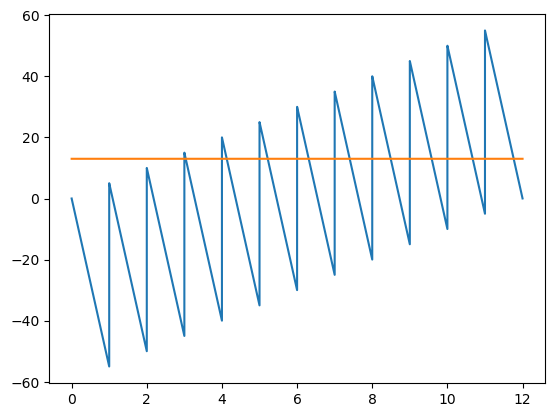

In [81]:
#plt.plot(df.time_hour, df.mark_hour)
#plt.plot(df.time_hour, df.mark_min)
plt.plot(df.time_hour, df.mark_diff)
plt.plot(df.time_hour, df.diff13)
plt.show()

In [87]:
df[np.abs(df.mark_diff - 13) < 1e-2]

,time_sec,time_hour,time_delta,mark_hour,mark_min,mark_diff,diff13
10931,10931,3.036389,0 days 03:02:11,15.181944,2.183333,12.998611,13
14858,14858,4.127222,0 days 04:07:38,20.636111,7.633333,13.002778,13
18785,18785,5.218056,0 days 05:13:05,26.090278,13.083333,13.006944,13
18786,18786,5.218333,0 days 05:13:06,26.091667,13.100000,12.991667,13
22713,22713,6.309167,0 days 06:18:33,31.545833,18.550000,12.995833,13
26640,26640,7.400000,0 days 07:24:00,37.000000,24.000000,13.000000,13
30567,30567,8.490833,0 days 08:29:27,42.454167,29.450000,13.004167,13
34494,34494,9.581667,0 days 09:34:54,47.908333,34.900000,13.008333,13
34495,34495,9.581944,0 days 09:34:55,47.909722,34.916667,12.993056,13
38422,38422,10.672778,0 days 10:40:22,53.363889,40.366667,12.997222,13


However, only one of these happens at a time where both hands are pointing exactly at one of the 60 marks: 07:24